# Hyperparameter-tuning超参数调优 笔记

## 7.1 参数调整过程
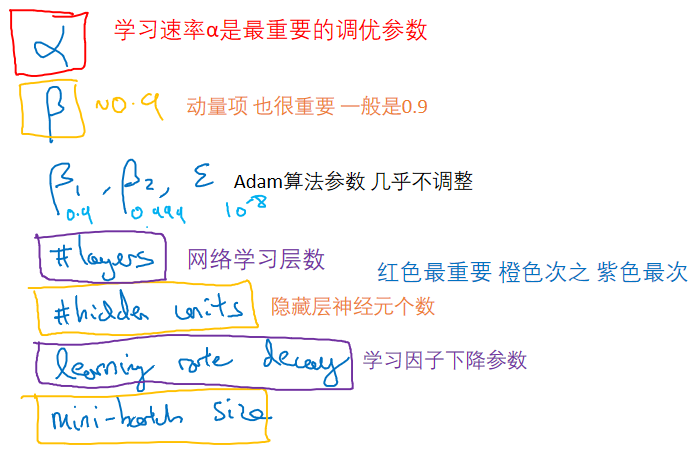

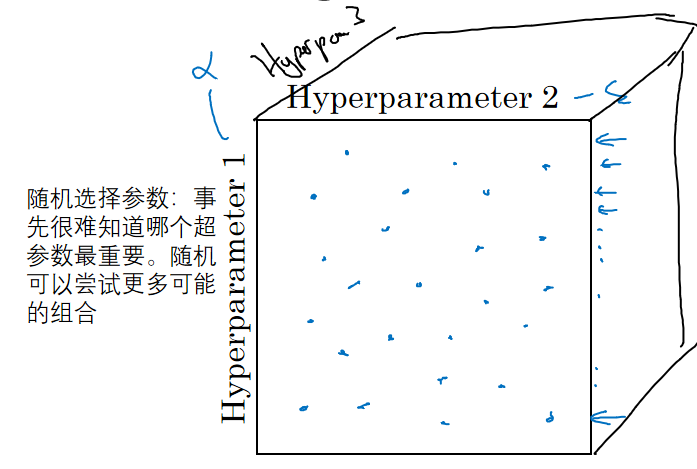

还有一种常见方法是使用**区域定位的抽样**方案coarse to fine：   
在某些效果最好的点所在的区域进行限定，然后在该区域进行密度更高的抽样。
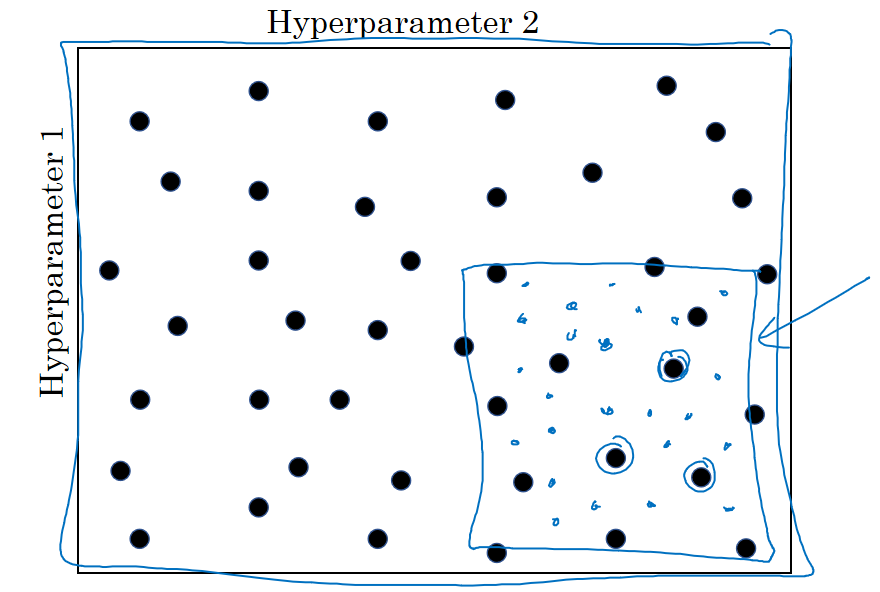

## 7.2 使用适当的尺度选择超参数
**对数尺度进行采样：**  
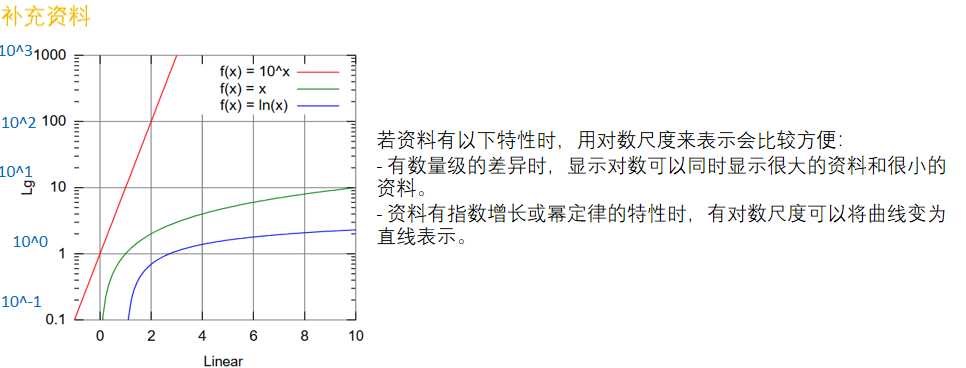

一般解法是，如果线性区间为[a, b]，令m=log(a)，n=log(b)，则对应的log区间为[m,n]。

对log区间的[m,n]进行随机均匀采样，然后得到的采样值r，最后反推到线性区间，即$10^r$。


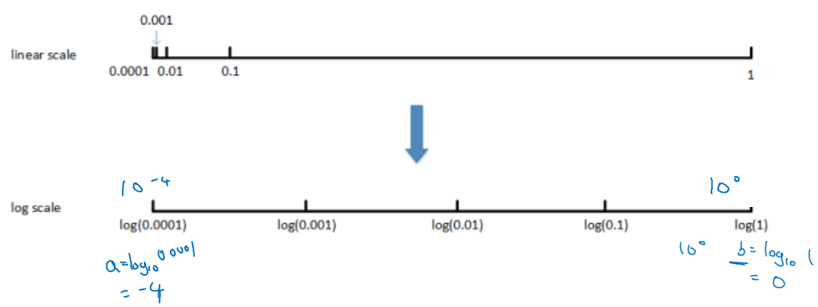

In [ ]:
#python代码实现如下
r = -4*np.random.rand()     # 首先随机取值，r∈[-4,0]
a = np.power(10,r)          # a ∈[10^-4,10^0]


除了α之外，动量梯度因子β也是一样，在超参数调试的时候也需要进行非均匀采样。
-  一般β的取值范围在[0.9, 0.999]之间，那么1−β的取值范围就在[0.001, 0.1]之间。那么直接对1−β在[0.001, 0.1]区间内进行log变换即可。
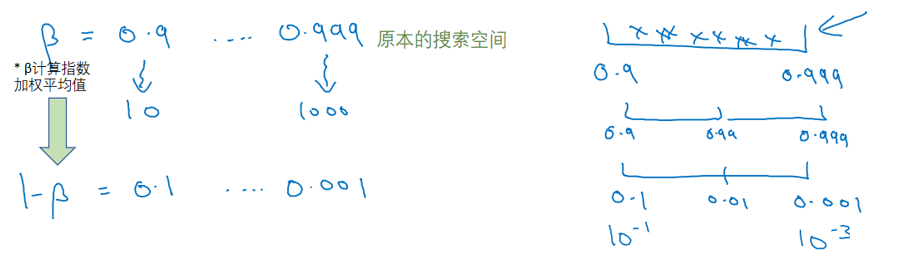
- 为什么要非线性变化呢？ 因为当β趋近于1时，结果对β的改变将会变得非常敏感❗所以需要在趋近于1的区域进行更大密度的取样

## 7.3 实践中的超参数调整
在训练深度神经网络时，一种情况是受计算能力所限，我们只能对一个模型进行训练，调试不同的超参数，使得这个模型有最佳的表现。要随时观察并调整参数，我们称之为Babysitting one model。         
另外一种情况是可以对**多个模型同时进行训练**，每个模型上调试不同的超参数，根据表现情况，选择最佳的模型。我们称之为Training many models in parallel。
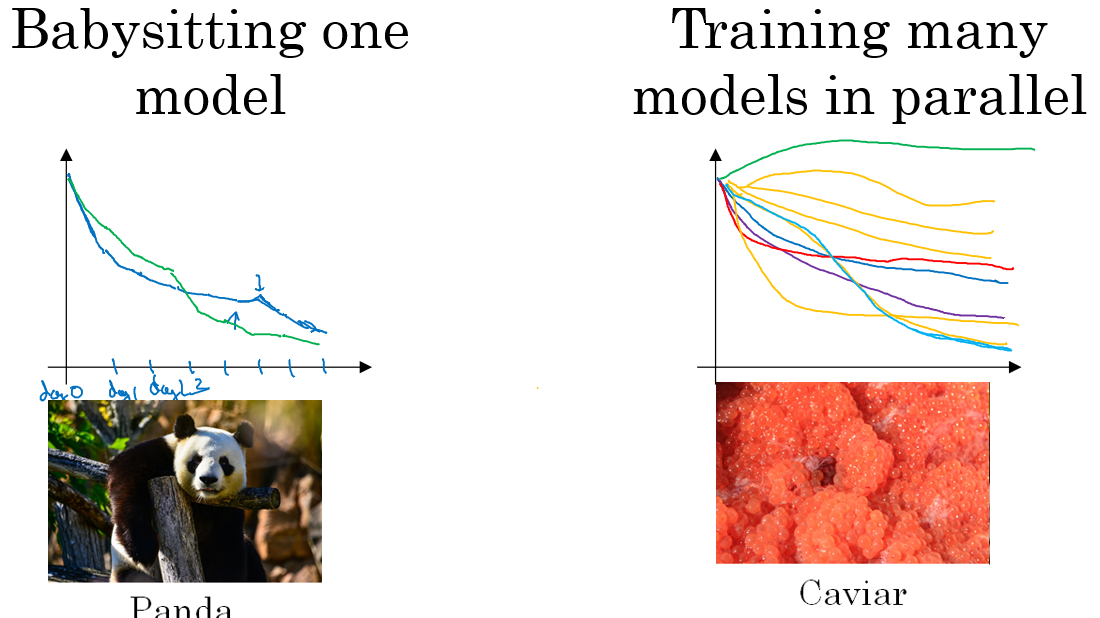


- 如何选择取决于计算资源：如果有足够的计算机来并行训练很多不同参数的模型，那么就直接选择右图的模式。

## 7.4 ❤批归一化Batch Normalization
【归一化隐藏范元激活函数用以加速学习的方法】     
不仅在输入层，而在一些隐藏层上也做归一化。注意，输入层和隐藏层的归一化有不同：可能不希望隐藏层一直是均值为0，方差为1
- 在BN出现之前，我们的归一化操作一般都在数据输入层，对输入的数据进行求均值以及求方差做归一化，但是BN的出现打破了这一个规定，我们可以在网络中任意一层进行归一化处理     

思路如下：
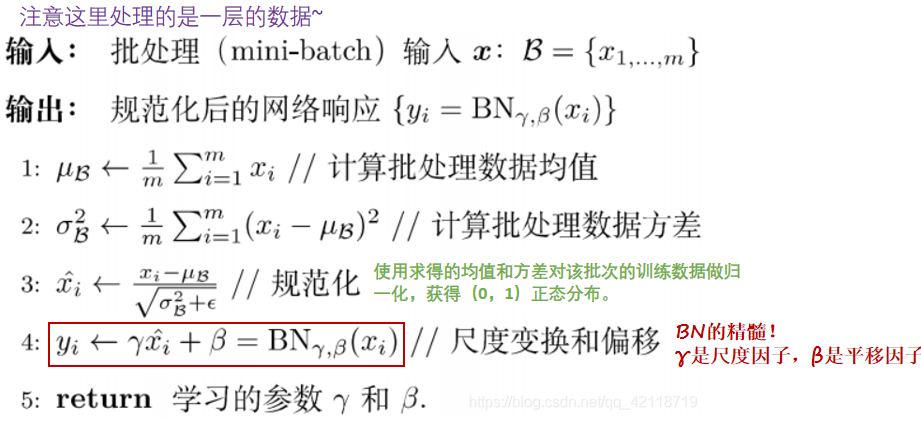

换句话说正态分布式的数据归一化变成了下面的形式来进行数据归一化

$$
x^*=\frac{\gamma(x-\mu)}{\sqrt{\sigma^2+\epsilon}}+\beta
$$

**BN的本质**  
这个链接讲的很好：[🔗](https://blog.csdn.net/qq_42118719/article/details/113544673#:~:text=%E5%9B%9B%E3%80%81-,BN%E7%9A%84%E6%9C%AC%E8%B4%A8,-%E4%B8%80%E4%B8%AA%E6%A0%87%E5%87%86%E7%9A%84)

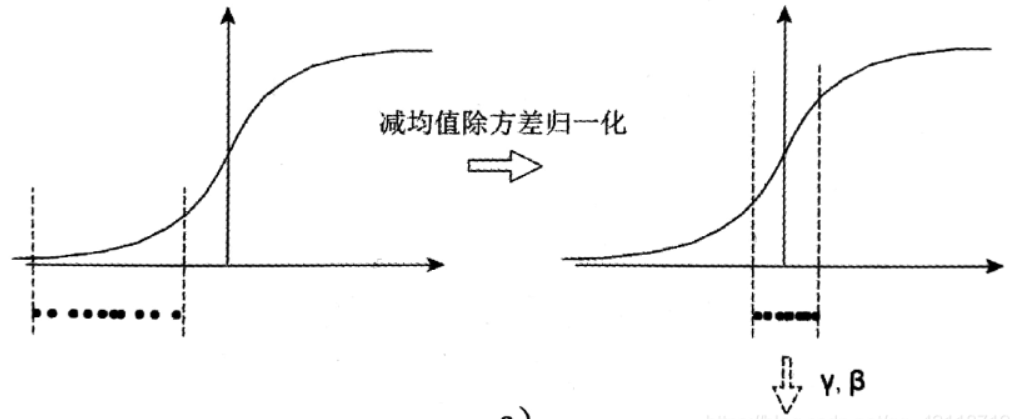
- 上图的sigmoid函数，在减均值除方差后，数据就被移到中心区域如右图所示，在-1~1之间的梯度变化不大，那么非线性变换的作用就不能很好的体现。换言之就是，减均值除方差操作后可能会削弱网络的性能。
- 我们会希望输入有更大的方差，以便利用sigmoid函数非线性的特性。

### 为啥要用BN？
- BN算法减少输入值变化所产生的影响，使值变得更稳定。
- BN有轻微正则化的效果
    - 每个mini-batch都进行均值为0，方差为1的归一化操作
    - 每个mini-batch中，对各个隐藏层的添加了随机噪声，效果类似于Dropout
    - mini-batch越小，正则化效果越明显。【当mini-batch较小时，每个mini-batch的样本代表性较差，计算出的均值和方差波动较大，BN引入的随机性较大，正则化效果也更明显。】
    - ⏰但是，Batch Norm的正则化效果比较微弱，正则化也只是个副作用

----
一般是在mini-batch里使用BN。对于每一个batch，都要依次进行操作
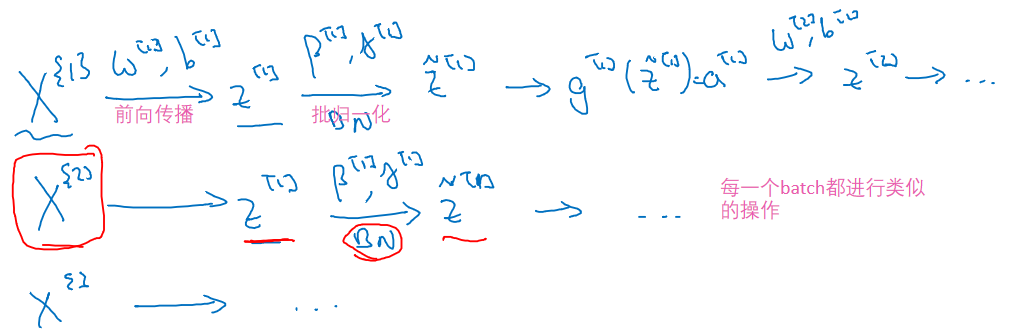

值得注意的是，因为Batch Norm对各隐藏层$Z^{l} ≡ W^{[l]}A^{l-1} + b^{[l]}$有去均值的操作，<font color='red'>所以这里的常数项$b^{[l]}$可以消去，其数值效果完全可以由$\tilde{Z}^{[l]}$中的β来实现</font>。因此，我们在使用Batch Norm的时候，可以忽略各隐藏层的常数项。除了传统的梯度下降算法之外，还可以使用我们之前介绍过的动量梯度下降、RMSprop或者Adam等优化算法.

## 7.7 测试时的batch Norm 
对于BN，当一个模型训练完成之后，它的所有参数都确定了，包括均值和方差，$\mu$和$\sigma$。  测试的时候，是一个一个样本进行测试的，所以没办法求 均值和 方差，所以可以用训练数据的。**因此，需要使用在训练阶段计算并存储的全局均值和方差。** 通常是实现某种指数加权平均，来记住$\mu$和$\sigma$,然后用这些估算值，在测试时进行比例缩放来获取隐藏神经元的z值。
<font color='red'>
- 训练阶段：在每个mini-batch上计算均值和方差，进行归一化，同时记录这些统计量。
- 测试阶段：使用训练阶段计算得到的全局均值和方差对每个测试样本进行归一化。
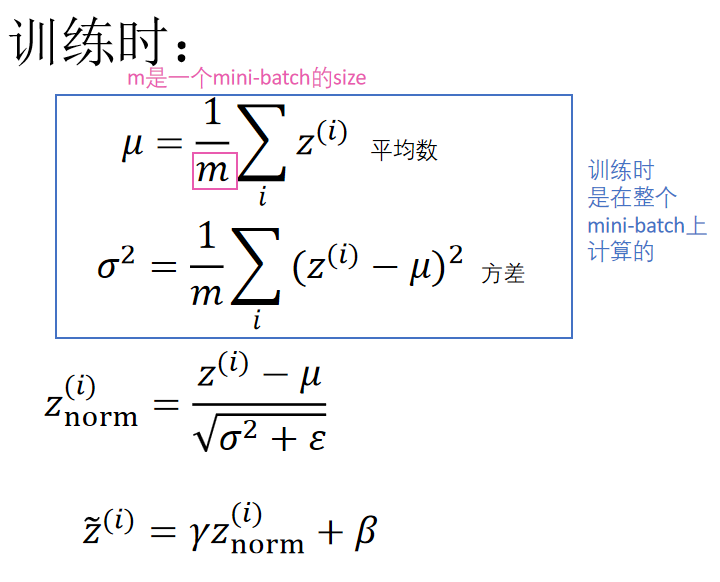

我们在用不同的mini-batch训练神经网络时，保持一个移动均值来记录每一层的$\mu$和$\sigma$。
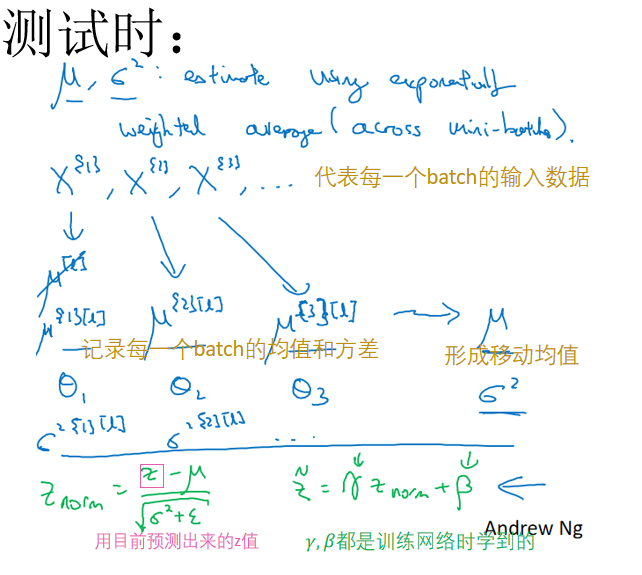

- 总结：使用Batch归一化，你能够训练更深的网络，让你的学习算法运行速度更快

## 7.8 Softmax回归
softmax回归是logistic回归从2分类到多分类的推广
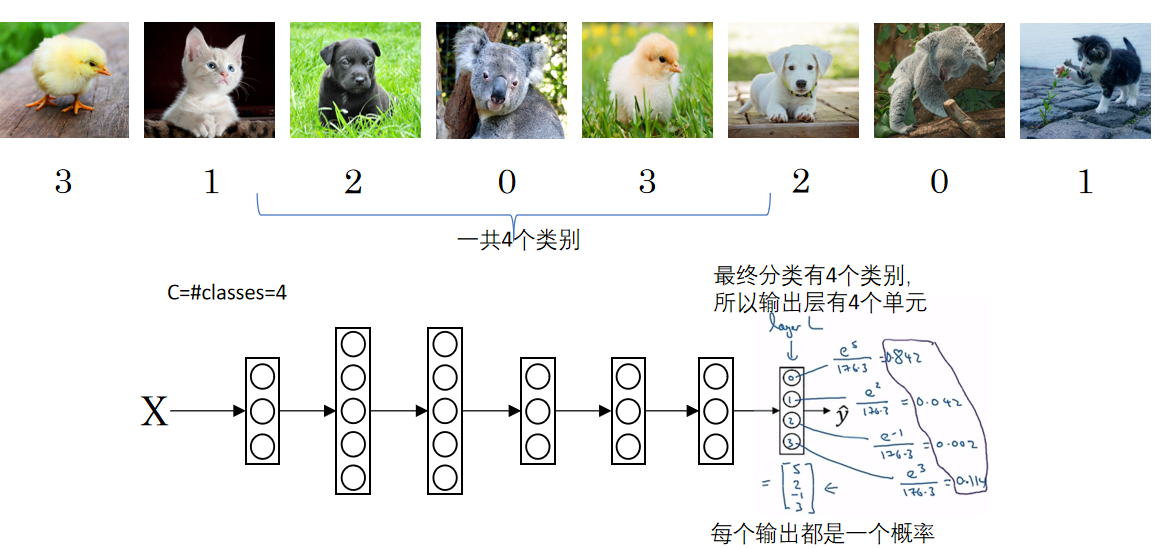

Actiation function：
$$
\begin{gathered}
z^{[L]}=W^{[L]} a^{[L-1]}+b^{[L]} \\
t=e^{z_i^{[L]}}\\
a_i^{[L]}=\frac{t}{\sum_{i=1}^C t_i}
\end{gathered}
$$
- 最终会算出总和为1的C个概率。
- 和其他激活函数不同的是，softmax的输入输出都是向量，且输出会归一化。

决策边界是线性的！

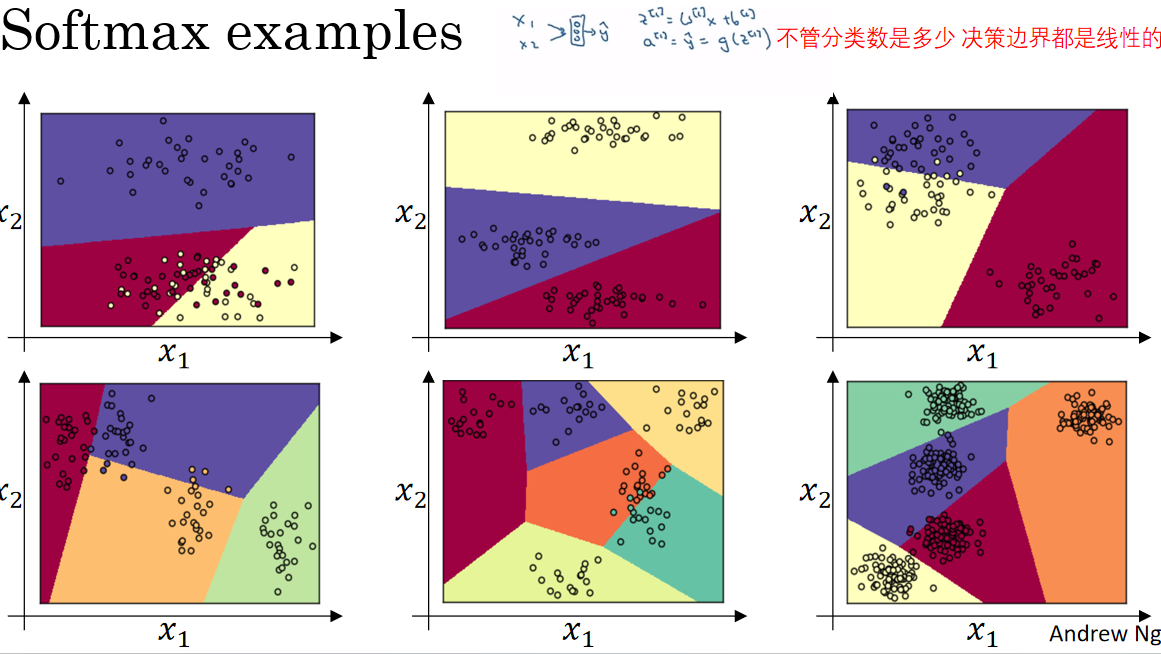

再来以一个具体例子来看看softmax，和hardmax的区别：

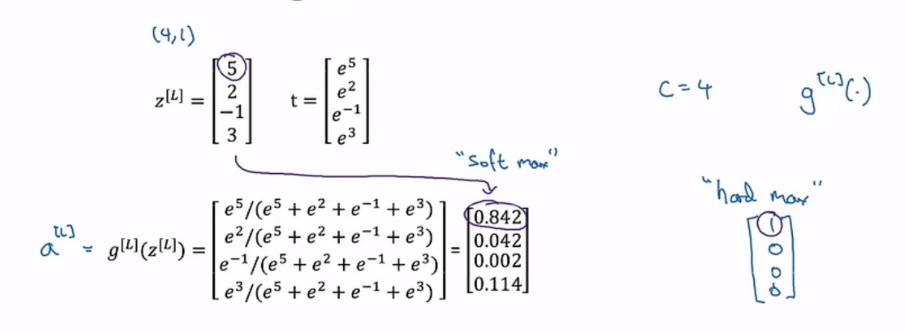

反向传播的公式：
$$dz^{[L]}=\hat{y}-y$$
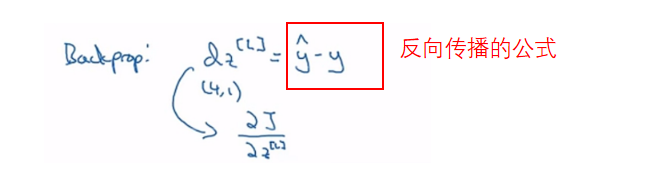

## 7.11 Tensorflow
TF不需要明确执行反向传播，在正向传播和计算图表的帮助下，TF就会自动找到所有必要的逆向计算。【代码见最后】

# 测试题
1. 在超参数搜索过程中，你尝试只照顾一个模型（使用熊猫策略）还是一起训练大量的模型（鱼子酱策略）在很大程度上取决于：

A. 【  】是否使用批量（batch）或小批量优化（mini-batch optimization）

B. 【  】神经网络中局部最小值（鞍点）的存在性

C. 【  】在你能力范围内，你能够拥有多大的计算能力（注：就是高性能电脑和低性能电脑的区别）

D. 【  】需要调整的超参数的数量

答案：

C.【 √ 】在你能力范围内，你能够拥有多大的计算能力（注：就是高性能电脑和低性能电脑的区别）

---------

2. 如果您认为β（动量超参数）介于0.9和0.99之间，那么推荐采用以下哪一种方法来对β值进行取样？

A. 【  】

r = np.random.rand()
beta = r * 0.09 + 0.9

B. 【  】

r = np.random.rand()
beta = 1 - 10 ** ( - r - 1 )

C. 【  】

r = np.random.rand()
beta = 1 - 10 ** ( - r + 1 )

D. 【  】

r = np.random.rand()
beta = r * 0.9 + 0.09

答案：

B.【 √ 】

r = np.random.rand()
beta = 1 - 10 ** ( - r - 1 )

分析：
r = np.random.rand()生成一个在 [0, 1) 范围内均匀分布的随机数。−r−1 将这个范围变为 [-2, -1)。这样10∗∗(−r−1)得到的结果是一个在 $10^{-2}$和$10^{-1}$之间的数，也就是 [0.01, 0.1) 范围内的数。

-----------
3. 在视频中介绍的批量标准化中，如果将其应用于神经网络的第l层，您应该对谁进行标准化？

A. 【  】$z^{[l]}$
 

B. 【  】$ W^{[l]}$
 

C. 【  】$ b^{[l]}$
 

D. 【  】$ b^{[l]}$
 

答案：

A.【 √ 】$ z^{[l]}$    
分析：批量标准化的主要目标是对每一层的线性变换输出 $z^{[l]}$进行标准化，以保证神经网络在训练过程中每层的输入具有更好的分布特性。

-----------
4. 批标准化中关于γ和β 的以下哪些陈述是正确的？

A. 【  】对于每个层，有一个全局值γ ∈ R \gamma \in \mathbb{R}γ∈R和一个全局值β ∈ R \beta \in \mathbb{R}β∈R，适用于于该层中的所有隐藏单元。

B. 【  】γ和β 是算法的超参数，我们通过随机采样进行调整

C. 【  】它们确定了给定层的线性变量z [ l ] z^{[l]}z 
[l]
 的均值和方差

D. 【  】最佳值是$ \gamma=\sqrt{\sigma^2+\epsilon},\beta=\mu$

E. 【  】它们可以用Adam、动量的梯度下降或RMSprop，而不仅仅是用梯度下降来学习

答案：

C.【 √ 】它们确定了给定层的线性变$z^{[l]}$ 的均值和方差

E.【 √ 】它们可以用Adam、动量的梯度下降或RMSprop，而不仅仅是用梯度下降来学习
<font color='#BD43534'>分析： 

A 解释： 这不完全正确。实际上，**γ 和 β 是针对每个神经元的独立参数，而不是整个层的全局值。每个隐藏单元（或特征）都有各自的 γ 和 β 参数**

B ： 这不正确。γ 和 β 是模型的可训练参数，而不是超参数。**它们是在训练过程中通过反向传播算法进行学习和更新的，而不是通过随机采样来调整的。**

D 解释： 这不正确。γ 和 β 是在训练过程中通过反向传播学习到的参数，而不是预设的固定值。它们的最佳值是通过训练数据学习得到的，而不是由某个公式确定的

E 解释： 这正确。γ 和 β 是模型的可训练参数，在训练过程中通过反向传播算法进行更新.可以使用任何优化算法来学习，包括 Adam、动量梯度下降、RMSprop 等。这些优化算法可以帮助更有效地调整这些参数以达到最佳性能

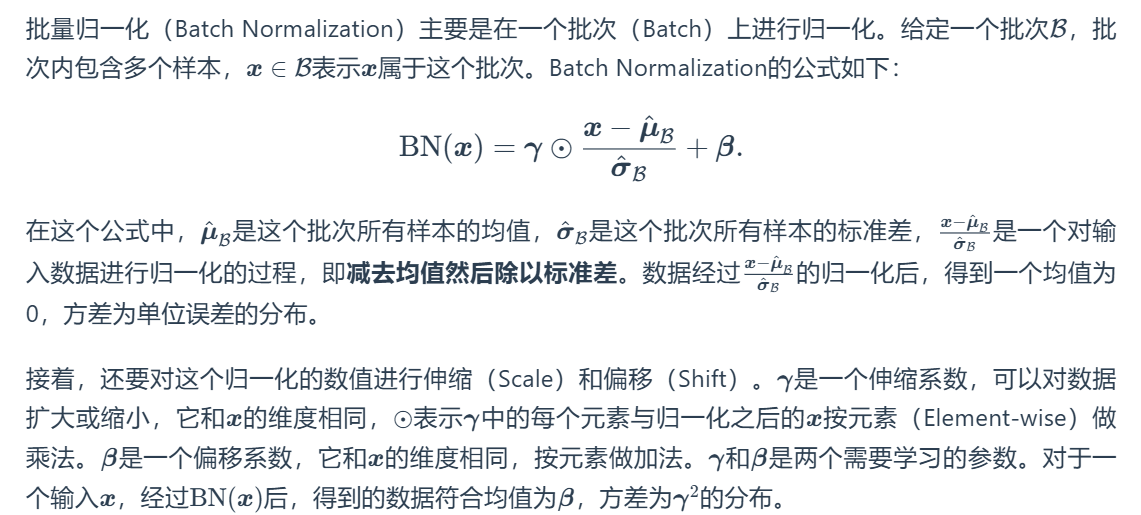

----------
5. 在训练了具有批标准化的神经网络之后，在用新样本评估神经网络的时候，您应该：

A. 【  】如果你在256个例子的mini-batch上实现了批标准化，那么如果你要在一个测试例子上进行评估，你应该将这个例子重复256次，这样你就可以使用和训练时大小相同的mini-batch进行预测。

B. 【  】使用最新的mini-batch的μ和$ \sigma^2$
2
 值来执行所需的标准化

C. 【  】跳过用μ和$ \sigma^2$ 
2
 值标准化的步骤，因为一个例子不需要标准化

D. 【  】执行所需的标准化，使用在训练期间，通过指数加权平均值得出的μ和$ \sigma^2$
 

答案：

D.【 √ 】执行所需的标准化，使用在训练期间，通过指数加权平均值得出的μ和$ \sigma^2$

# Tensorflow

In [1]:
import tensorflow as tf
tf.compat.v1.enable_eager_execution()

In [2]:
import numpy as np


# 初始值
x = np.array([1.0, -10.0, 25.0], dtype=np.float32)
w = tf.Variable(0.0, dtype=tf.float32)  # 初始化w变量

optimizer = tf.keras.optimizers.Adam(0.1)

def training(x, w, optimizer):
    # 定义成本函数
    def cost_fn():
        return x[0] * w**2 + x[1] * w + x[2]
    
    # 运行优化器
    for i in range(1000):
        optimizer.minimize(cost_fn, [w])
    
    return w

# 执行训练
w = training(x, w, optimizer)

In [4]:
print(w.numpy())  #将TensorFlow变量w转换为NumPy值并打印出来。

5.000001
